# Universal Format (UF)

In [1]:
import cmweather  # noqa
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching Universal Format radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
import atexit
from pathlib import Path
from tempfile import TemporaryDirectory

tmpdir_obj = TemporaryDirectory()
atexit.register(tmpdir_obj.cleanup)  # remove even if you forget
tmpdir = Path(tmpdir_obj.name)


def get_temp_file(fname):
    import gzip
    import shutil

    fnamei = Path(DATASETS.fetch(fname))
    fnameo = tmpdir / fnamei.stem
    with gzip.open(fnamei) as fin:
        with open(fnameo, "wb") as fout:
            shutil.copyfileobj(fin, fout)
            fout.flush()
            fout.close()
    return fnameo


fname = get_temp_file("20110427_164233_rvp8-rel_v001_SUR.uf.gz")

## xr.open_dataset

Making use of the xarray `uf` backend. We also need to provide the group. Note, that we are using CfRadial2 group access pattern.

In [3]:
ds = xr.open_dataset(fname, group="sweep_0", engine="uf")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 23MB
Dimensions:            (azimuth: 318, range: 997)
Coordinates:
  * azimuth            (azimuth) float64 3kB 22.88 23.88 24.91 ... 338.9 339.9
    elevation          (azimuth) float64 3kB ...
  * range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
    time               (azimuth) datetime64[us] 3kB ...
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           int64 8B ...
Data variables: (12/14)
    DBZH               (azimuth, range) float64 3MB ...
    DBTH               (azimuth, range) float64 3MB ...
    VRADH              (azimuth, range) float64 3MB ...
    WRADH              (azimuth, range) float64 3MB ...
    ZDR                (azimuth, range) float64 3MB ...
    KDP                (azimuth, range) float64 3MB ...
    ...                 ...
    RHOHV              (azimuth, range) float64 3MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:           Sigmet/UF
    site_name:        MAX
    instrument_name:  rvp8-rel
    comment:          Sigmet I

In [4]:
import numpy as np

np.testing.assert_almost_equal(ds.sweep_fixed_angle.values, 0.703125)

### Plot Time vs. Azimuth

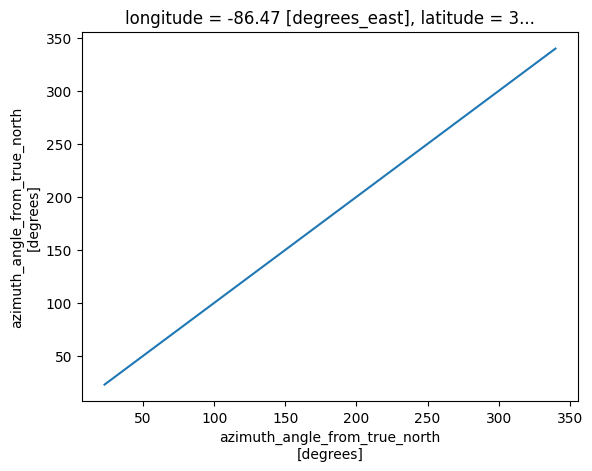

In [5]:
ds.azimuth.plot()

### Plot Range vs. Time

We need to sort by time and specify the y-coordinate.

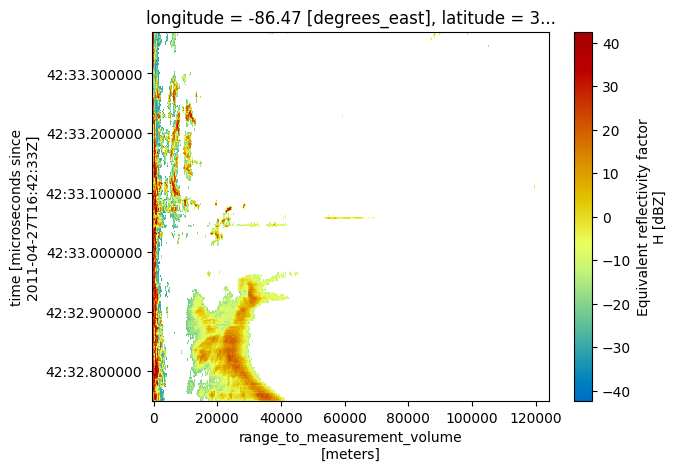

In [6]:
ds.DBZH.sortby("time").plot(y="time", cmap="HomeyerRainbow")

### Plot Range vs. Azimuth


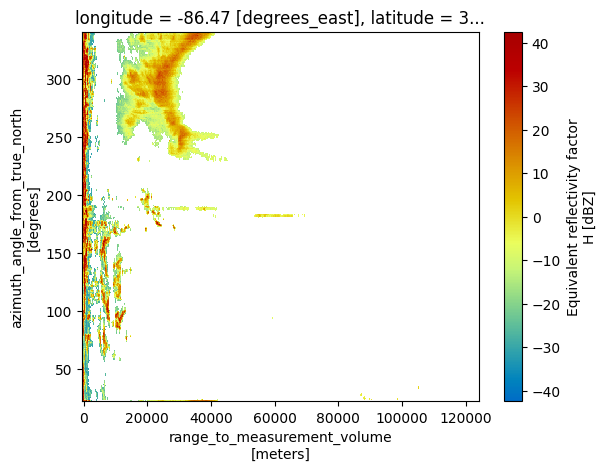

In [7]:
ds.DBZH.plot(cmap="HomeyerRainbow")

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the `uf` backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [8]:
help(xd.io.UFBackendEntrypoint)

Help on class UFBackendEntrypoint in module xradar.io.backends.uf:

class UFBackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for Universal Format (UF) data.
 |
 |  Method resolution order:
 |      UFBackendEntrypoint
 |      xarray.backends.common.BackendEntrypoint
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  open_dataset(
 |      self,
 |      filename_or_obj,
 |      *,
 |      mask_and_scale=True,
 |      decode_times=True,
 |      concat_characters=True,
 |      decode_coords=True,
 |      drop_variables=None,
 |      use_cftime=None,
 |      decode_timedelta=None,
 |      group=None,
 |      lock=None,
 |      first_dim='auto',
 |      reindex_angle=False,
 |      fix_second_angle=False,
 |      site_coords=True,
 |      optional=True
 |  )
 |      Backend open_dataset method used by Xarray in :py:func:`~xarray.open_dataset`.
 |
 |  ----------------------------------------------------------------------
 |  Data and other attri

In [9]:
ds = xr.open_dataset(fname, group="sweep_0", engine="uf", first_dim="time")
display(ds)

<xarray.Dataset> Size: 23MB
Dimensions:            (time: 318, range: 997)
Coordinates:
    azimuth            (time) float64 3kB ...
    elevation          (time) float64 3kB ...
  * range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
  * time               (time) datetime64[us] 3kB 2011-04-27T16:42:32.749970 ....
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           int64 8B ...
Data variables: (12/14)
    DBZH               (time, range) float64 3MB ...
    DBTH               (time, range) float64 3MB ...
    VRADH              (time, range) float64 3MB ...
    WRADH              (time, range) float64 3MB ...
    ZDR                (time, range) float64 3MB ...
    KDP                (time, range) float64 3MB ...
    ...                 ...
    RHOHV              (time, range) float64 3MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:           Sigmet/UF
    site_name:        MAX
    instrument_name:  rvp8-rel
    comment:          Sigmet I

## open_uf_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list.

In [10]:
help(xd.io.open_uf_datatree)

Help on function open_uf_datatree in module xradar.io.backends.uf:

open_uf_datatree(
    filename_or_obj,
    mask_and_scale=True,
    decode_times=True,
    concat_characters=True,
    decode_coords=True,
    drop_variables=None,
    use_cftime=None,
    decode_timedelta=None,
    sweep=None,
    first_dim='auto',
    reindex_angle=False,
    fix_second_angle=False,
    site_coords=True,
    optional=True,
    lock=None,
    **kwargs
)
    Open a Universal Format (UF) dataset as :py:class:`xarray.DataTree`.

    This function loads UF radar data into a DataTree structure, which
    organizes radar sweeps as separate nodes. Provides options for decoding time
    and applying various transformations to the data.

    Parameters
    ----------
    filename_or_obj : str, Path, file-like, or DataStore
        The path or file-like object representing the radar file.
        Path-like objects are interpreted as local or remote paths.

    mask_and_scale : bool, optional
        If True, re

In [11]:
dtree = xd.io.open_uf_datatree(fname, sweep=4)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2011-04-27T16:43:51Z'
│       time_coverage_end    <U20 80B '2011-04-27T16:43:52Z'
│       longitude            float64 8B -86.47
│       altitude             int64 8B 226
│       latitude             float64 8B 34.93
│   Attributes:
│       Conventions:      None
│       instrument_name:  rvp8-rel
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet/UF
│       history:          None
│       comment:          Sigmet I
│       site_name:        MAX
├── Group: /sweep_4
│       Dimensions:            (azimuth: 318, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 22.86 23.86 24.88 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 3.688 3.766 3.812 ... 3.891 3.859
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:43:52 ... 2...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBTH               (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           ZDR                (azimuth, range) float64 3MB ...
│           KDP                (azimuth, range) float64 3MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 3MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 4
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 3.797
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -86.47
│           latitude   float64 8B 34.93
│           altitude   int64 8B 226
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -86.47
│           latitude   float64 8B 34.93
│           altitude   int64 8B 226
└── Group: /radar_calibration

### Plot Sweep Range vs. Time

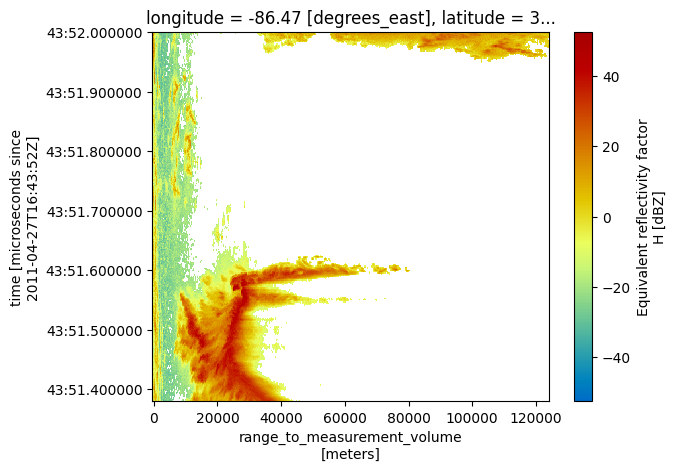

In [12]:
dtree["sweep_4"].ds.DBZH.sortby("time").plot(y="time", cmap="HomeyerRainbow")

### Plot Sweep Range vs. Azimuth

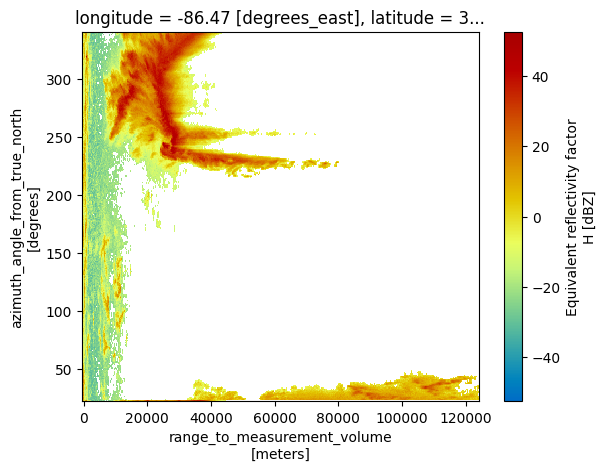

In [13]:
dtree["sweep_4"].ds.DBZH.plot(cmap="HomeyerRainbow")

In [14]:
dtree = xd.io.open_uf_datatree(fname, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2011-04-27T16:45:10Z'
│       time_coverage_end    <U20 80B '2011-04-27T16:45:11Z'
│       longitude            float64 8B -86.47
│       altitude             int64 8B 226
│       latitude             float64 8B 34.93
│   Attributes:
│       Conventions:      None
│       instrument_name:  rvp8-rel
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet/UF
│       history:          None
│       comment:          Sigmet I
│       site_name:        MAX
├── Group: /sweep_8
│       Dimensions:            (azimuth: 329, range: 919)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.875 1.875 21.88 ... 358.9 359.9
│           elevation          (azimuth) float64 3kB 10.09 10.05 9.688 ... 10.14 10.12
│           range              (range) float32 4kB -436.5 -311.5 ... 1.142e+05 1.143e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:45:11.34954...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 2MB ...
│           DBTH               (azimuth, range) float64 2MB ...
│           VRADH              (azimuth, range) float64 2MB ...
│           WRADH              (azimuth, range) float64 2MB ...
│           ZDR                (azimuth, range) float64 2MB ...
│           KDP                (azimuth, range) float64 2MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 2MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 8
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 10.0
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -86.47
│           latitude   float64 8B 34.93
│           altitude   int64 8B 226
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B -86.47
│           latitude   float64 8B 34.93
│           altitude   int64 8B 226
└── Group: /radar_calibration

In [15]:
dtree = xd.io.open_uf_datatree(fname, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2011-04-27T16:42:32Z'
│       time_coverage_end    <U20 80B '2011-04-27T16:45:11Z'
│       longitude            float64 8B -86.47
│       altitude             int64 8B 226
│       latitude             float64 8B 34.93
│   Attributes:
│       Conventions:      None
│       instrument_name:  rvp8-rel
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet/UF
│       history:          None
│       comment:          Sigmet I
│       site_name:        MAX
├── Group: /sweep_0
│       Dimensions:            (azimuth: 318, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 22.88 23.88 24.91 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 0.25 0.25 0.25 ... 0.2656 0.25
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:42:33.36911...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBTH               (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           ZDR                (azimuth, range) float64 3MB ...
│           KDP                (azimuth, range) float64 3MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 3MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.7031
├── Group: /sweep_1
│       Dimensions:            (azimuth: 319, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 21.88 22.86 23.89 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 1.0 1.0 0.9688 ... 0.8906 0.8906
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:42:53.45895...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBTH               (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           ZDR                (azimuth, range) float64 3MB ...
│           KDP                (azimuth, range) float64 3MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 3MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 1.297
├── Group: /sweep_8
│       Dimensions:            (azimuth: 329, range: 919)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.875 1.875 21.88 ... 358.9 359.9
│           elevation          (azimuth) float64 3kB 10.09 10.05 9.688 ... 10.14 10.12
│           range              (range) float32 4kB -436.5 -311.5 ... 1.142e+05 1.143e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:45:11.34954...
│           longitude         

In [16]:
dtree["sweep_0"]["sweep_fixed_angle"].values

array(0.703125)

In [17]:
dtree["sweep_8"]["sweep_fixed_angle"].values

array(10.)

In [18]:
dtree = xd.io.open_uf_datatree(fname)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              ()
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2011-04-27T16:42:32Z'
│       time_coverage_end    <U20 80B '2011-04-27T16:46:50Z'
│       longitude            float64 8B -86.47
│       altitude             int64 8B 226
│       latitude             float64 8B 34.93
│   Attributes:
│       Conventions:      None
│       instrument_name:  rvp8-rel
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet/UF
│       history:          None
│       comment:          Sigmet I
│       site_name:        MAX
├── Group: /sweep_0
│       Dimensions:            (azimuth: 318, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 22.88 23.88 24.91 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 0.25 0.25 0.25 ... 0.2656 0.25
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:42:33.36911...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBTH               (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           ZDR                (azimuth, range) float64 3MB ...
│           KDP                (azimuth, range) float64 3MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 3MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 0
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 0.7031
├── Group: /sweep_1
│       Dimensions:            (azimuth: 319, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 21.88 22.86 23.89 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 1.0 1.0 0.9688 ... 0.8906 0.8906
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:42:53.45895...
│           longitude          float64 8B -86.47
│           latitude           float64 8B 34.93
│           altitude           int64 8B 226
│       Data variables: (12/14)
│           DBZH               (azimuth, range) float64 3MB ...
│           DBTH               (azimuth, range) float64 3MB ...
│           VRADH              (azimuth, range) float64 3MB ...
│           WRADH              (azimuth, range) float64 3MB ...
│           ZDR                (azimuth, range) float64 3MB ...
│           KDP                (azimuth, range) float64 3MB ...
│           ...                 ...
│           RHOHV              (azimuth, range) float64 3MB ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           sweep_number       int64 8B 1
│           prt_mode           <U7 28B 'not_set'
│           follow_mode        <U7 28B 'not_set'
│           sweep_fixed_angle  float64 8B 1.297
├── Group: /sweep_2
│       Dimensions:            (azimuth: 319, range: 997)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 21.88 22.88 23.89 ... 338.9 339.9
│           elevation          (azimuth) float64 3kB 1.594 1.578 1.578 ... 1.562 1.547
│           range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
│           time               (azimuth) datetime64[us] 3kB 2011-04-27T16:43:13.54489...
│           longitude         

In [19]:
dtree["sweep_1"]

<xarray.DataTree 'sweep_1'>
Group: /sweep_1
    Dimensions:            (azimuth: 319, range: 997)
    Coordinates:
      * azimuth            (azimuth) float64 3kB 21.88 22.86 23.89 ... 338.9 339.9
        elevation          (azimuth) float64 3kB 1.0 1.0 0.9688 ... 0.8906 0.8906
        range              (range) float32 4kB -436.5 -311.5 ... 1.239e+05 1.241e+05
        time               (azimuth) datetime64[us] 3kB 2011-04-27T16:42:53.45895...
        longitude          float64 8B -86.47
        latitude           float64 8B 34.93
        altitude           int64 8B 226
    Data variables: (12/14)
        DBZH               (azimuth, range) float64 3MB ...
        DBTH               (azimuth, range) float64 3MB ...
        VRADH              (azimuth, range) float64 3MB ...
        WRADH              (azimuth, range) float64 3MB ...
        ZDR                (azimuth, range) float64 3MB ...
        KDP                (azimuth, range) float64 3MB ...
        ...                 ...
        RHOHV              (azimuth, range) float64 3MB ...
        sweep_mode         <U20 80B 'azimuth_surveillance'
        sweep_number       int64 8B 1
        prt_mode           <U7 28B 'not_set'
        follow_mode        <U7 28B 'not_set'
        sweep_fixed_angle  float64 8B 1.297

## clean up

In [20]:
import time

for node in dtree.values():
    if hasattr(node, "close"):
        node.close()
for file in tmpdir.iterdir():
    if file.is_file():
        for _ in range(5):
            try:
                file.unlink()
                break
            except PermissionError:
                time.sleep(0.5)